In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.inspection import PartialDependenceDisplay
 
from scipy.stats import norm, rankdata
from scipy.optimize import minimize
from sklearn.metrics import r2_score
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube
 
from skopt.sampler import Lhs
from skopt.space import Space
 
import shap
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Helper Functions

In [2]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 
# MC dropout prediction
# model must be in train() mode so dropout stays active during prediction
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1 - week 7

Function 1 - Week 7
Largest gap: -19.6 to -39.6
Floor set at: -29.6
Strongest detection: -3.606063e-03 at [0.65011406 0.68152635]
  log reading: -2.4
Log reading range: -29.6 to -2.4

All points (sorted by detection strength):
  [0.65011406 0.68152635] -> output: -3.606e-03 -> log reading: -2.4
  [0.694651 0.629916] -> output: -1.607e-03 -> log reading: -2.8
  [0.461537 0.459084] -> output: -1.688e-05 -> log reading: -4.8
  [0.73102363 0.73299988] -> output: 7.711e-16 -> log reading: -15.1
  [0.618043 0.460066] -> output: 2.603e-20 -> log reading: -19.6
  [0.914142 0.732619] -> output: -2.694e-65 -> log reading: -29.6
  [0.37454  0.950714] -> output: -1.561e-117 -> log reading: -29.6
  [0.959184 0.836735] -> output: -5.910e-107 -> log reading: -29.6
  [0.88388983 0.58225397] -> output: 6.230e-48 -> log reading: -29.6
  [0.08250725 0.40348751] -> output: 3.607e-81 -> log reading: -29.6
  [0.68341817 0.86105746] -> output: 2.535e-40 -> log reading: -29.6
  [0.31269116 0.07872278] -> outp

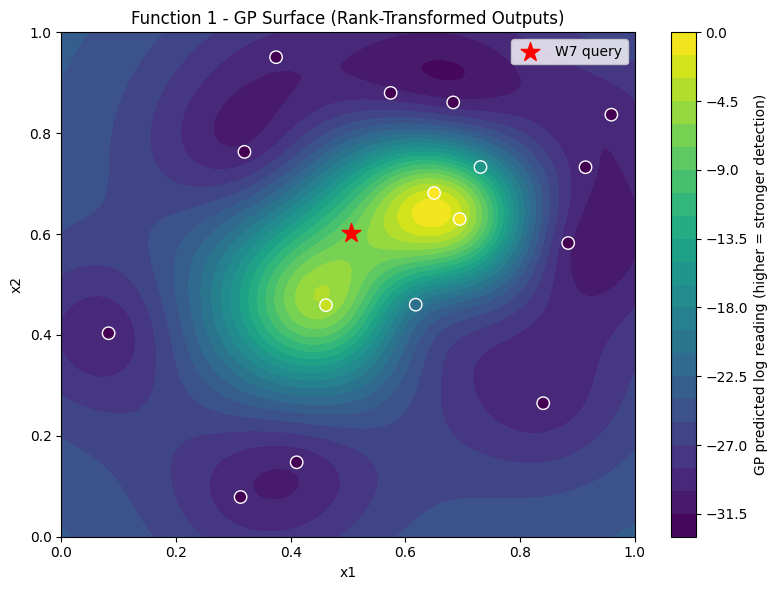

In [11]:
# =============================================================================
# FUNCTION 1 - Radiation Detection (2D)
# changes: 
#     - replaced signal mask with rank transform on all outputs, mapping outputs to [1, 2, ..., N]
#          rank transform preserving order without magnitude distortion
#     - added 2D heatmap of GP predicted surface with data overlay for interpretability 
# =============================================================================
 
print("=" * 60)
print("Function 1 - Week 7")
print("=" * 60)
 
inputs  = np.load('../Data/function_1/initial_inputs.npy')
outputs = np.load('../Data/function_1/initial_outputs.npy')
 
prev_queries = np.array([
    [0.959184, 0.836735],  
    [0.374540, 0.950714],  
    [0.694651, 0.629916],  
    [0.461537, 0.459084],  
    [0.618043, 0.460066], 
    [0.914142, 0.732619],  
])
prev_outputs = np.array([
    -5.909566597235814e-107,
    -1.560646704467778e-117,
    -0.0016067678433140744,
    -0.000016877758079573665,
    2.602669489913104e-20,
    -2.694395789176799e-65,
])
 
all_inputs  = np.vstack([inputs, prev_queries])
all_outputs = np.hstack([outputs, prev_outputs])
 
# log-abs transform to measure detection strength
# largest absolute value = strongest detection = highest log reading
# 1e-300 prevents log(0) for any exactly-zero readings
log_readings = np.log10(np.abs(all_outputs) + 1e-300)

# find the natural gap between signal and dead zone
# set floor at the midpoint of the largest gap in sorted log readings
sorted_logs = np.sort(log_readings)[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

# clip: all dead-zone points get the same floor value
# preventing the GP's uncertainty from exploding in empty regions
log_readings = np.clip(log_readings, floor, 0)
 
# identify the strongest detection
best_detection_idx = np.argmax(log_readings)
print(f"Strongest detection: {all_outputs[best_detection_idx]:.6e} at {all_inputs[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}")
 
print(f"\nAll points (sorted by detection strength):")
sort_idx = np.argsort(log_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs[i]} -> output: {all_outputs[i]:.3e} -> log reading: {log_readings[i]:.1f}")
 
# GP on log readings
kernel = Matern(nu=2.5, length_scale=0.15, length_scale_bounds="fixed")
gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(all_inputs, log_readings)
 
# global candidates with UCB 
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))

kappa = 4.0 
mu, sigma = gp.predict(candidates, return_std=True)
ucb       = compute_ucb(mu, sigma, kappa)
 
best_idx = np.argmax(ucb)
query    = candidates[best_idx]
 
print(f"\nWeek 7 Query: {format_query(query)}")
print(f"mu (log reading): {mu[best_idx]:.2f}, sigma: {sigma[best_idx]:.2f}")
 
# --- Interpretability: 2D heatmap of GP predicted surface
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
 
mu_grid, _ = gp.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)
 
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs[:, 0], all_inputs[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query[0], query[1], marker='*', c='red', s=200, zorder=10, label='W7 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Rank-Transformed Outputs)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 2 - week 7 


Function 2 - Week 7
Total points: 16
Current best: 0.675
Feature importances: x1=0.892, x2=0.108

Week 7 Query: 0.627660-0.941490
  Ensemble mean: 0.501
  Tree std:      0.212
  UCB score:     0.819  (kappa=1.5)


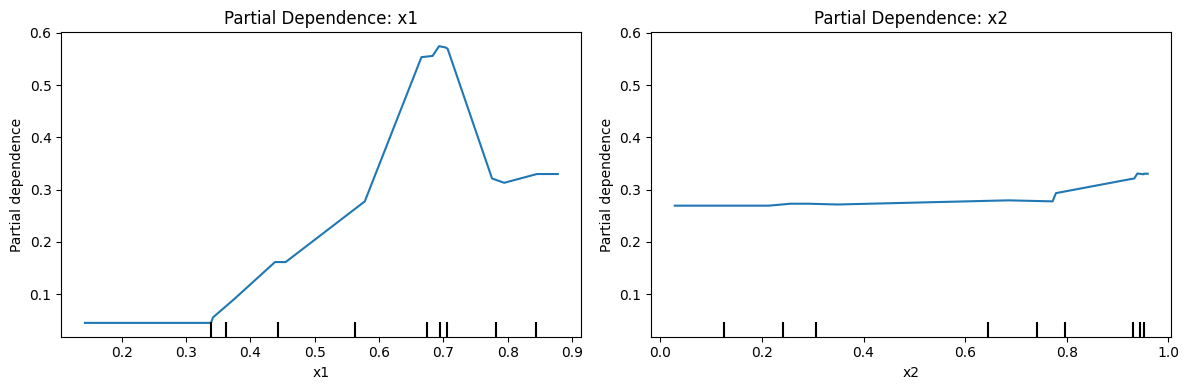

In [4]:
# =============================================================================
# FUNCTION 2 - Noisy Log-Likelihood (2D)
# changes: 
#     - replace single-tree Thompson with full-ensemble UCB (kappa=1.5) using tree std as uncertainty (W6 approach).
#     - interpretability: added 1D partial dependence plot for x1
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 2 - Week 7")
print("=" * 60)
 
initial_inputs  = np.load('../Data/function_2/initial_inputs.npy')
initial_outputs = np.load('../Data/function_2/initial_outputs.npy')
 
prev_queries = np.array([
    [0.775510, 0.959184],  # W1: 0.166
    [0.683114, 0.932567],  # W2: 0.570
    [0.794441, 0.256481],  # W3: 0.273
    [0.706387, 0.952221],  # W4: 0.675 (best)
    [0.693183, 0.938929],  # W5: 0.674
    [0.374540, 0.950714],  # W6: 0.096 
])
prev_outputs = np.array([0.16576674, 0.56974583, 0.27313450, 0.67545988, 0.67430262, 0.09612224849190841])
 
all_inputs  = np.vstack([initial_inputs, prev_queries])
all_outputs = np.hstack([initial_outputs, prev_outputs])
 
print(f"Total points: {len(all_outputs)}")
print(f"Current best: {all_outputs.max():.3f}")
 
# RF -- same settings as W6
rf = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)
print(f"Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}")
 
# full-ensemble UCB
# tree std measures disagreement across 500 trees for uncertainty
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))
 
tree_preds = np.array([trees.predict(candidates) for trees in rf.estimators_])
mean_pred  = tree_preds.mean(axis=0)
std_pred   = tree_preds.std(axis=0)
kappa = 1.5
ucb_scores = mean_pred + kappa * std_pred
 
best_idx = np.argmax(ucb_scores)
query    = candidates[best_idx]
 
print(f"\nWeek 7 Query: {format_query(query)}")
print(f"  Ensemble mean: {mean_pred[best_idx]:.3f}")
print(f"  Tree std:      {std_pred[best_idx]:.3f}")
print(f"  UCB score:     {ucb_scores[best_idx]:.3f}  (kappa=1.5)")
 
# --- Interpretability: 1D partial dependence for x1 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf, all_inputs, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()

# Function 3 - week 7


Function 3 - Week 7
Total points: 21, best: -0.0000607

RF feature importances:
  A     : 0.0325
  B     : 0.0176
  C     : 0.3473
  A*B   : 0.0240
  A*C   : 0.0143
  B*C   : 0.0443
  A^2   : 0.0155
  B^2   : 0.0889
  C^2   : 0.4155

RF train R²: 0.7200

Week 7 Query: 0.427601-0.442546-0.649322
  Ensemble mean: -0.053386
  Tree std:      0.076720
  UCB score:     0.061694  (kappa = 1.5)


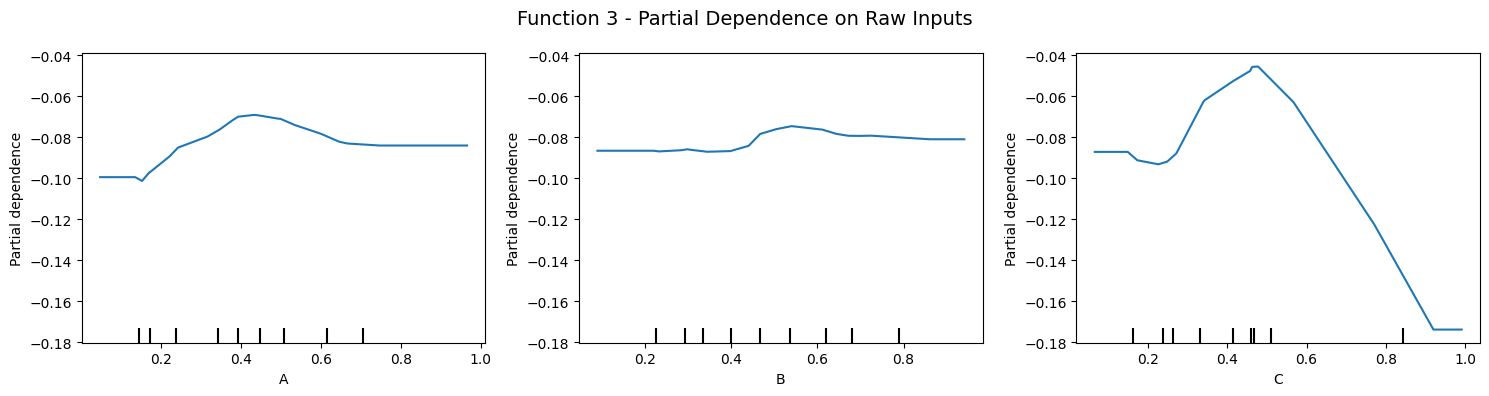

In [5]:
# =============================================================================
# FUNCTION 3 - Drug Discovery (3D)
# changes:
#   -  max_features=None (was 'sqrt') sqrt underweighting interaction terms (A*B, B*C, A*C) only seeing 3 of 9 poly features per split
#   -  added ensemble UCB (tree std) instead of argmax. 
#   - interpretability: added 2D partial dependence plots for (B,C) and (A,C) interactions
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 3 - Week 7")
print("=" * 60)
 
f3_inputs  = np.load('../Data/function_3/initial_inputs.npy')
f3_outputs = np.load('../Data/function_3/initial_outputs.npy')
 
prev_queries = np.array([
    [0.378956, 0.302768, 0.459346],  # W1: -0.0291
    [0.315339, 0.088659, 0.415174],  # W2: -0.0623
    [0.392735, 0.504381, 0.464332],  # W3: -0.000633
    [0.498607, 0.467046, 0.477827],  # W4: -0.00294
    [0.432840, 0.535542, 0.476983],  # W5: -0.000617
    [0.442511, 0.539648, 0.462840],  # W6: -0.0000607 (new best by 10x)
])
prev_outputs = np.array([
    -0.02906213067759293,
    -0.06230989251412482,
    -0.0006328364393800658,
    -0.0029446702316140265,
    -0.0006169444563794807,
    -0.00006071018004296725,
])
 
X = np.vstack([f3_inputs, prev_queries])
Y = np.hstack([f3_outputs, prev_outputs])
 
print(f"Total points: {len(Y)}, best: {Y.max():.7f}")
 
# polynomial features -- explicit compound interactions
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
 
feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']
 
# ExtraTrees on polynomial features
# max_features=None: all 9 features visible at each split (was 'sqrt' which was 3 features only)
# giving the trees a better chance of learning interaction structure
rf = ExtraTreesRegressor(n_estimators=200, max_features=None, min_samples_leaf=2, random_state=42)
rf.fit(X_poly, Y)
 
print("\nRF feature importances:")
for name, imp in zip(feature_names, rf.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")
 
train_preds = rf.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds):.4f}")
 
# candidate generation -- same as W6
np.random.seed(42)
candidates = np.random.uniform(0, 1, (10000, 3))
cand_poly  = poly.transform(candidates)
 
# ensemble UCB instead of argmax
# tree std measures where ExtraTrees disagrees = where model is uncertain
tree_preds = np.array([trees.predict(cand_poly) for trees in rf.estimators_])
mean_pred  = tree_preds.mean(axis=0)
std_pred   = tree_preds.std(axis=0)
kappa = 1.5
ucb_scores = mean_pred + kappa * std_pred
 
best_idx = np.argmax(ucb_scores)
query    = candidates[best_idx]
 
print(f"\nWeek 7 Query: {format_query(query)}")
print(f"  Ensemble mean: {mean_pred[best_idx]:.6f}")
print(f"  Tree std:      {std_pred[best_idx]:.6f}")
print(f"  UCB score:     {ucb_scores[best_idx]:.6f}  (kappa = {kappa})")
 
# --- Interpretability Plots ---
rf_raw = ExtraTreesRegressor(n_estimators=200, max_features=None, min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence on Raw Inputs', fontsize=14)
plt.tight_layout()
plt.show()

# Function 4 - week 7


Function 4 - Week 7
Total points: 36, best: 0.6309

SVM Classifier:
  Threshold: -1.1
  Above threshold: 3/36

Candidates: 8280 local (SVM filtered) + 2000 global = 10280 total

Week 7 Query: 0.447976-0.395249-0.406174-0.473345
mean: 0.656
std:  0.629
EI:   0.258450


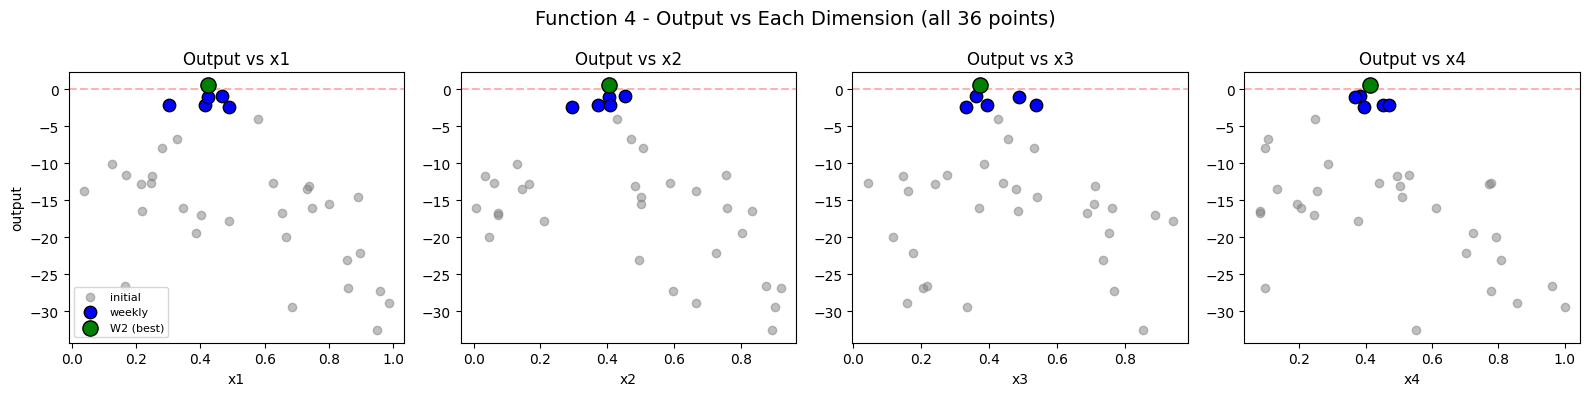

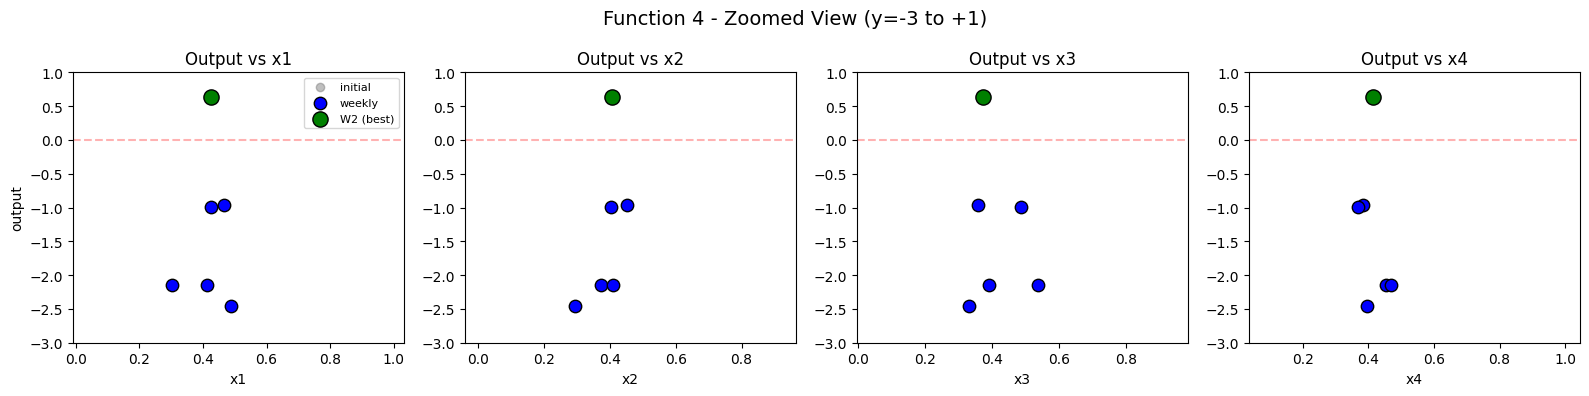

In [6]:
# =============================================================================
# FUNCTION 4 - Warehouse Placement (4D)
# changes:
#   -  GP alpha raised from 1e-6 to 0.05 because the function wis described as "dynamic and full of local optima"
#          alpha=0.05 allows the GP to smooth over noise rather than interpolating every point exactly.
#   - added 2000 global LHS candidates alongside local search
#   - interpretability: added SVM decision boundary visualised as 2D slice (x2 vs x3)
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 4 - Week 7")
print("=" * 60)
 
f4_inputs  = np.load('../Data/function_4/initial_inputs.npy')
f4_outputs = np.load('../Data/function_4/initial_outputs.npy')
 
prev_queries = np.array([
    [0.466173, 0.451984, 0.359193, 0.383111],  # W1: -0.965
    [0.424201, 0.406375, 0.372722, 0.413313],  # W2: +0.631 (best)
    [0.413541, 0.373697, 0.536536, 0.453354],  # W3: -2.150
    [0.424125, 0.404716, 0.487507, 0.367688],  # W4: -0.992
    [0.488793, 0.294975, 0.332280, 0.395576],  # W5: -2.463
    [0.303872, 0.408521, 0.392275, 0.469543],  # W6: -2.141
])
prev_outputs = np.array([
    -0.9654345395220925, 0.6308582112564989, -2.1500998298742817,
    -0.9915950770116662, -2.4630197287139697, -2.1414388028868454,
])
 
f4_all_inputs  = np.vstack([f4_inputs, prev_queries])
f4_all_outputs = np.hstack([f4_outputs, prev_outputs])
 
print(f"Total points: {len(f4_all_outputs)}, best: {f4_all_outputs.max():.4f}")
 
# SVM Classifier -- same threshold and setup as W6
threshold = -1.1
y_binary = (f4_all_outputs > threshold).astype(int)
 
print(f"\nSVM Classifier:")
print(f"  Threshold: {threshold}")
print(f"  Above threshold: {y_binary.sum()}/{len(y_binary)}")
 
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(f4_all_inputs, y_binary)
 
# Candidate generation -- same local search as W6 plus global LHS
np.random.seed(42)
 
week1_query = np.array([0.466173, 0.451984, 0.359193, 0.383111])
week2_query = np.array([0.424201, 0.406375, 0.372722, 0.413313])
week4_query = np.array([0.424125, 0.404716, 0.487507, 0.367688])
 
# local search -- same as W6
local_search = []
for centre, n in [(week2_query, 3500), (week1_query, 2000), (week4_query, 1500)]:
    for _ in range(n):
        candidate = np.clip(centre + np.random.normal(0, 0.05, 4), 0, 1)
        local_search.append(candidate)
 
# feature-weighted -- same as W6
feature_weighted = []
for _ in range(3000):
    candidate = week2_query.copy()
    candidate += np.random.normal(0, 0.1, 4)
    candidate = np.clip(candidate, 0, 1)
    candidate[2] = np.clip(candidate[2], 0, 0.42)   # x3 cap
    candidate[1] = np.clip(candidate[1], 0.38, 1)    # x2 floor
    feature_weighted.append(candidate)
 
# global LHS candidates 
global_lhs = LatinHypercube(d=4, seed=42).random(n=2000)
 
# stream 1: local candidates go through SVM
local_and_fw = np.vstack([local_search, feature_weighted])
svm_probs = svm.predict_proba(local_and_fw)[:, 1]
filtered_local = local_and_fw[svm_probs > 0.3]

# stream 2: global candidates skip SVM
# let the GP's EI decide if any distant region is worth exploring
global_lhs = LatinHypercube(d=4, seed=42).random(n=2000)

candidates = np.vstack([filtered_local, global_lhs])
print(f"\nCandidates: {len(filtered_local)} local (SVM filtered) + {len(global_lhs)} global = {len(candidates)} total")
 
# GP -- same ARD kernel as W6 but alpha increased from 1e-6 to 0.05
# alpha=0.05 lets the GP smooth over noise (reducing overfitting)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.3, 0.3, 0.2, 0.3],
    length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 0.5), (0.1, 2.0)],
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-4, normalize_y=True)
gp.fit(f4_all_inputs, f4_all_outputs)
 
mu, sigma = gp.predict(candidates, return_std=True)
ei = compute_ei(mu, sigma, f4_all_outputs.max(), xi=0.01)
 
best_index = np.argmax(ei)
query = candidates[best_index]
 
print(f"\nWeek 7 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f}")
print(f"std:  {sigma[best_index]:.3f}")
print(f"EI:   {ei[best_index]:.6f}")
 
# --- Interpretability ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']
for i, ax in enumerate(axes):
    ax.scatter(f4_all_inputs[:, i], f4_all_outputs, c='grey', alpha=0.5, label='initial')
    ax.scatter(prev_queries[:, i], prev_outputs, c='blue', edgecolors='black', s=80, label='weekly')
    # highlight W2
    ax.scatter(prev_queries[1, i], prev_outputs[1], c='green', edgecolors='black', s=120, zorder=5, label='W2 (best)')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('output' if i == 0 else '')
    ax.set_title(f'Output vs {dim_names[i]}')
axes[0].legend(fontsize=8)
plt.suptitle('Function 4 - Output vs Each Dimension (all 36 points)', fontsize=14)
plt.tight_layout()
plt.show()

# plot only my queries
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.scatter(f4_all_inputs[:, i], f4_all_outputs, c='grey', alpha=0.5, label='initial')
    ax.scatter(prev_queries[:, i], prev_outputs, c='blue', edgecolors='black', s=80, label='weekly')
    ax.scatter(prev_queries[1, i], prev_outputs[1], c='green', edgecolors='black', s=120, zorder=5, label='W2 (best)')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_ylim(-3, 1)  # zoom in
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('output' if i == 0 else '')
    ax.set_title(f'Output vs {dim_names[i]}')
axes[0].legend(fontsize=8)
plt.suptitle('Function 4 - Zoomed View (y=-3 to +1)', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5 - week 7


Function 5 - Week 7
Total points: 26, best so far: 4354.08

Week 7 Query:       0.681041-0.999999-0.999999-0.999999
GP predicted yield: 4058.31
GP std (log scale): 0.4157
SVR prediction:     4937.95
EI:                 0.130899

--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         2201.8     2201.8     2078.6
W2         2381.5     2381.5     2253.4
W3         2689.2     2689.2     2578.2
W4         3223.2     3223.2     3351.3
W5         3287.0     3287.0     3394.0
W6         4354.1     4354.1     4226.9

--- x1 sensitivity check ---
    x1   GP yield  SVR yield
  0.40     4550.1     3563.1
  0.50     4651.9     4245.6
  0.55     4604.9     4547.7
  0.60     4466.3     4780.4
  0.65     4238.3     4914.1
  0.70     3936.7     4928.8
  0.75     3585.1     4818.1
  0.80     3208.9     4590.4

--- x2 sensitivity check ---
    x2   GP yield  SVR yield
  0.85     3058.2     3389.9
  0.90     3558.7     3754.2
  0.92     3773.6     3892.3
  0.95     41

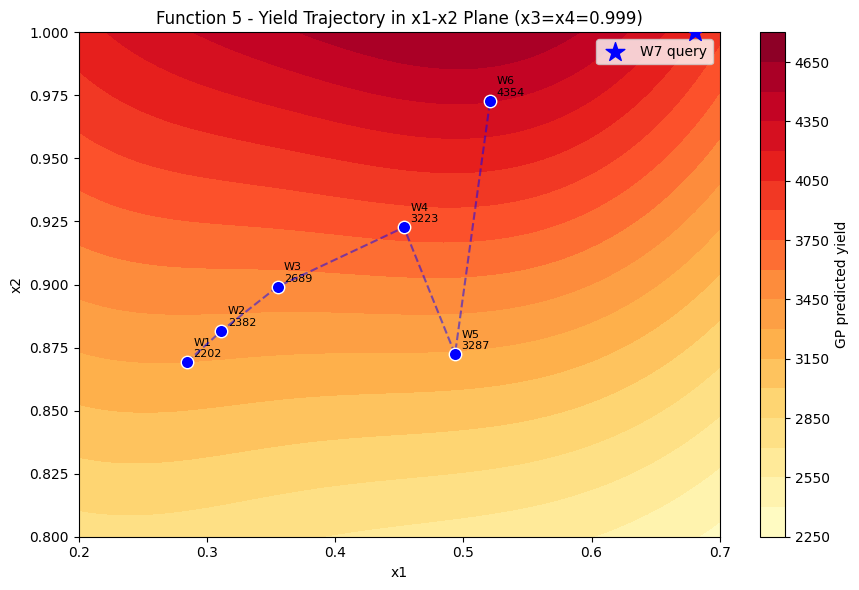

In [12]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
# changes: 
#    - SVR candidate pre-filter raised from 500 back to 3000 (original)
#    - No surrogate or acquisition function changes since the pipeline is working
#    - interpretability: added trajectory plot in x1-x2 plane with GP surface overla
#        and GP vs SVR prediction comparison at all historical query points
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 5 - Week 7")
print("=" * 60)
 
f5_inputs  = np.load('../Data/function_5/initial_inputs.npy')
f5_outputs = np.load('../Data/function_5/initial_outputs.npy')
 
prev_queries = np.array([
    [0.284290, 0.869208, 0.999999, 0.903273],  # W1: 2201.83
    [0.311208, 0.881577, 0.999999, 0.915050],  # W2: 2381.54
    [0.355085, 0.899160, 0.999900, 0.934196],  # W3: 2689.15
    [0.453609, 0.922659, 0.999999, 0.960267],  # W4: 3223.24
    [0.493503, 0.872392, 0.999999, 0.999999],  # W5: 3286.99
    [0.520874, 0.972838, 0.999999, 0.999999],  # W6: 4354.08
])
prev_outputs = np.array([
    2201.834589108927, 2381.536867607932, 2689.1537294933396,
    3223.2410694936825, 3286.9929500236235, 4354.076520735467,
])
 
all_inputs  = np.vstack([f5_inputs, prev_queries])
all_outputs = np.hstack([f5_outputs, prev_outputs])
 
print(f"Total points: {len(all_outputs)}, best so far: {all_outputs.max():.2f}")
 
# SVR -- same as W6
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()
 
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr.fit(X_scaled, Y_scaled)
 
# GP on log-transformed outputs -- same as W6
y_log     = np.log1p(all_outputs)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp.fit(all_inputs, y_log)
 
best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)
 
# local candidates -- same as W6 with x3+x4 pinned
local = []
for _ in range(6000):
    c    = best_point + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    c[3] = 0.999999  # x4 pinned
    local.append(c)
 
# directed candidates -- x1 up, x2 symmetric, x3+x4 pinned
directed = []
for _ in range(4000):
    c    = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.05)), 0, 1)   # x1 up
    c[1] = np.clip(c[1] + np.random.normal(0, 0.03), 0, 1)        # x2 symmetric
    c[2] = 0.999999
    c[3] = 0.999999
    directed.append(c)
 
candidates = np.vstack([local, directed])
 
# SVR pre-filter: top 3000
X_cand_scaled = input_scaler.transform(candidates)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()
 
top_idx  = np.argsort(svr_preds)[-3000:]
filtered = candidates[top_idx]
 
# GP + EI on log scale
mu_log, sigma_log = gp.predict(filtered, return_std=True)
ei                = compute_ei(mu_log, sigma_log, np.log1p(all_outputs.max()), xi=0.005)
 
best_idx = np.argmax(ei)
query    = filtered[best_idx]
 
print(f"\nWeek 7 Query:       {format_query(query)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx]:.4f}")
print(f"SVR prediction:     {svr_preds[top_idx[best_idx]]:.2f}")
print(f"EI:                 {ei[best_idx]:.6f}")
 
# --- Interpretability: GP vs SVR comparison at all query points ---
print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries, prev_outputs)):
    gp_pred  = np.expm1(gp.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")
 
# --- Interpretability: stats and plots ---

# check what GP and SVR predict at different values
print("\n--- x1 sensitivity check ---")
print(f"{'x1':>6} {'GP yield':>10} {'SVR yield':>10}")
for x1_val in [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    test_point = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x1_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


# check x2
print("\n--- x2 sensitivity check ---")
print(f"{'x2':>6} {'GP yield':>10} {'SVR yield':>10}")
for x2_val in [0.85, 0.90, 0.92, 0.95, 0.97, 0.99, 1.00]:
    test_point = np.array([[best_point[0], x2_val, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x2_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")
    
# plots
grid_n = 80
x1_range = np.linspace(0.2, 0.7, grid_n)
x2_range = np.linspace(0.8, 1.0, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)
 
# evaluate GP at grid with x3=x4=0.999
grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                            np.full(grid_n**2, 0.999999),
                            np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)
 
plt.figure(figsize=(9, 6))
plt.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
plt.colorbar(label='GP predicted yield')
# overlay trajectory
for i in range(len(prev_queries)):
    plt.scatter(prev_queries[i, 0], prev_queries[i, 1], c='blue',
                edgecolors='white', s=80, zorder=5)
    plt.annotate(f'W{i+1}\n{prev_outputs[i]:.0f}',
                 (prev_queries[i, 0]+0.005, prev_queries[i, 1]+0.002), fontsize=8)
# draw trajectory line
plt.plot(prev_queries[:, 0], prev_queries[:, 1], 'b--', alpha=0.5, zorder=4)
plt.scatter(query[0], query[1], marker='*', c='blue', s=200, zorder=10, label='W7 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 5 - Yield Trajectory in x1-x2 Plane (x3=x4=0.999)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 6 - week 7


Function 6 - Week 7
Total observations: 26, best so far: -0.3148

Random Forest feature importances:
  x1: 0.0556
  x2: 0.1272
  x3: 0.0366
  x4: 0.4531
  x5: 0.3275

Week 7 Query: 0.896209-0.283983-0.594508-0.806739-0.008612
  Predicted mean: -0.7043
  Predicted std:  0.4063
  UCB score:      -0.0949  (kappa=1.5)


/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_79392/3575798217.py:64: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs,


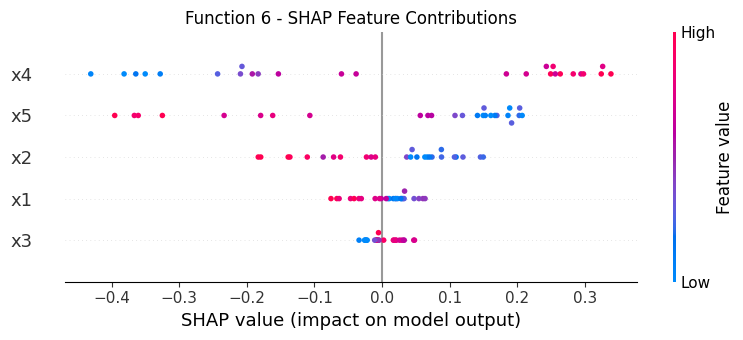

In [8]:
# =============================================================================
# FUNCTION 6 - Cake Recipe (5D)
# change: 
#    - configured RF: added max_depth=5, min_samples_leaf=2
#         previously was default settings (unlimited depth)
#    - interpretability: added SHAP summary plot on the RF
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 6 - Week 7")
print("=" * 60)
 
f6_inputs  = np.load('../Data/function_6/initial_inputs.npy')
f6_outputs = np.load('../Data/function_6/initial_outputs.npy')
 
prev_queries = np.array([
    [0.201818, 0.220639, 0.476414, 0.867793, 0.023115],  # W1: -0.792
    [0.457382, 0.349799, 0.529520, 0.691032, 0.192589],  # W2: -0.362
    [0.503404, 0.328861, 0.662838, 0.995031, 0.025514],  # W3: -0.368
    [0.484266, 0.300747, 0.678836, 0.776480, 0.244496],  # W4: -0.315 (best)
    [0.341066, 0.113474, 0.924694, 0.877339, 0.257942],  # W5: -0.829
    [0.408506, 0.262542, 0.745611, 0.998966, 0.244739],  # W6: -0.563
])
prev_outputs = np.array([-0.792246, -0.361637, -0.367626, -0.314817, -0.828981, -0.5633934601648388])
 
all_inputs  = np.vstack([f6_inputs, prev_queries])
all_outputs = np.hstack([f6_outputs, prev_outputs])
 
print(f"Total observations: {all_inputs.shape[0]}, best so far: {all_outputs.max():.4f}")
 
# RF with depth limit 
rf = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)
 
print("\nRandom Forest feature importances:")
for i, importance in enumerate(rf.feature_importances_):
    print(f"  x{i+1}: {importance:.4f}")
 
# Maximin LHS candidates -- same as W6
space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)
candidates = np.array(lhs.generate(space.dimensions, 5000))
 
# full-ensemble UCB -- same as W6 with kappa=1.5
kappa      = 1.5
tree_preds = np.array([t.predict(candidates) for t in rf.estimators_])
mean_pred  = tree_preds.mean(axis=0)
std_pred   = tree_preds.std(axis=0)
ucb_scores = mean_pred + kappa * std_pred
 
best_index = np.argmax(ucb_scores)
query      = candidates[best_index]
 
print(f"\nWeek 7 Query: {format_query(query)}")
print(f"  Predicted mean: {mean_pred[best_index]:.4f}")
print(f"  Predicted std:  {std_pred[best_index]:.4f}")
print(f"  UCB score:      {ucb_scores[best_index]:.4f}  (kappa={kappa})")
 
# --- Interpretability: SHAP summary plot ---
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(all_inputs)
 
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions')
plt.tight_layout()
plt.show()

# Function 7 - week 7


Function 7 - Week 7
Total points: 36, best: 2.6016

Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.712
  HP2: 0.064
  HP3: 0.036
  HP4: 0.020
  HP5: 0.051
  HP6: 0.118

Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 10
Output range in subset: 0.008 to 2.602

Filtered RF importance:
  HP1: 0.245  (was 0.712 in full dataset) ***
  HP2: 0.315  (was 0.064 in full dataset) ***
  HP3: 0.066  (was 0.036 in full dataset) 
  HP4: 0.107  (was 0.020 in full dataset) 
  HP5: 0.088  (was 0.051 in full dataset) 
  HP6: 0.178  (was 0.118 in full dataset) 

SHAP analysis (filtered RF, diagnostic):
  Feature    |SHAP|  Mean SHAP
  HP1         0.185     +0.025
  HP2         0.243     -0.023
  HP3         0.030     +0.004
  HP4         0.045     +0.001
  HP5         0.051     +0.028
  HP6         0.067     +0.034

Directional signals (top-performers comparison):
  Feature  Source         Top mean   Avg mean  Direction
  HP1      full          

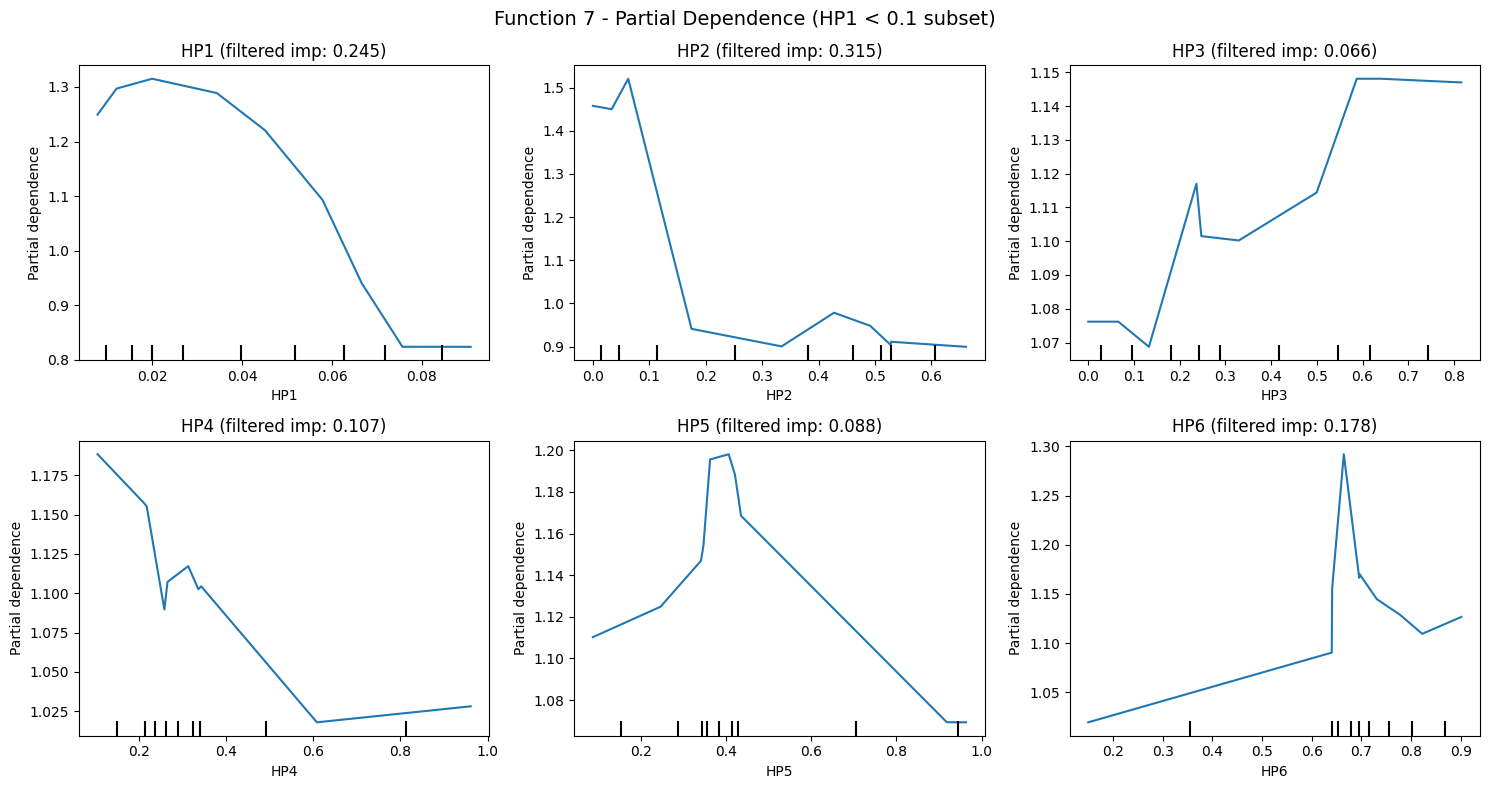

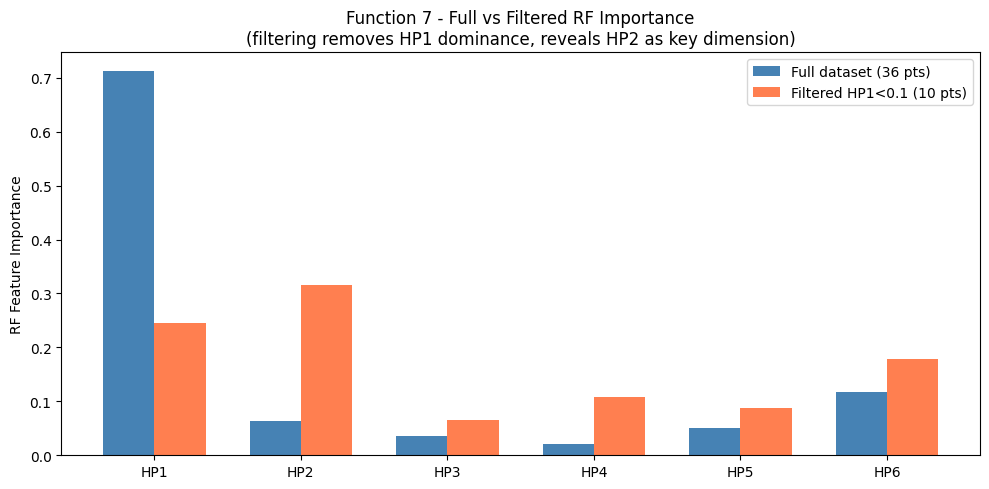

In [9]:
# =============================================================================
# FUNCTION 7 - ML Hyperparameters (6D)
# changes: 
#    - added a filtered RF (only points with HP1 < 0.1) to compute importance and directional signals for subspace bounds
#    - filtered RF shows HP2 is the most important dimension (0.315) -- full-dataset RF rated it at 0.064
#    - restore W3's dynamic bound-setting: importance controls width and directional signal controls placement
#    - interpretability: partial dependence on the filtered RF (HP1 < 0.1 subset), comparison of full-dataset vs filtered importance
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 7 - Week 7")
print("=" * 60)
 
f7_inputs  = np.load('../Data/function_7/initial_inputs.npy')
f7_outputs = np.load('../Data/function_7/initial_outputs.npy')
 
prev_queries = np.array([
    [0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164],  # W1: 1.051
    [0.034389, 0.427542, 0.236649, 0.342956, 0.405706, 0.695527],  # W2: 1.653
    [0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539],  # W3: 2.602 (best)
    [0.012096, 0.033240, 0.640160, 0.336533, 0.245422, 0.901043],  # W4: 1.509
    [0.007872, 0.174935, 0.499616, 0.265730, 0.340533, 0.150339],  # W5: 0.383
    [0.020000, 0.000000, 0.000000, 0.212520, 0.346351, 0.696182],  # W6: 1.790
])
prev_outputs = np.array([
    1.0510006614196026, 1.6531363312716738, 2.6016443512251484,
    1.5087286481808686, 0.3832671270292543, 1.789927976010441,
])
 
all_inputs  = np.vstack([f7_inputs, prev_queries])
all_outputs = np.hstack([f7_outputs, prev_outputs])
 
print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")
 
feature_names = [f"HP{i+1}" for i in range(6)]
 
# Step 1a: Full-dataset RF (for HP1 bounds -- HP1 is the dominant split)
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs, all_outputs)
 
print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")
 
# Step 1b: Filtered RF (HP1 < 0.1 subset)
# the full-dataset RF is dominated by HP1, masking the other dimensions
print("\nStep 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)")
hp1_mask = all_inputs[:, 0] < 0.1
filtered_inputs  = all_inputs[hp1_mask]
filtered_outputs = all_outputs[hp1_mask]
 
print(f"Points with HP1 < 0.1: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")
 
rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)
 
print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")
 
# SHAP on filtered RF -- diagnostic only, does not drive bounds
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)
 
print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")
 
# combine importance: full RF for HP1 and HP6, filtered RF for HP2-HP5
importance_combined = np.zeros(6)
importance_combined[0]   = rf_full.feature_importances_[0]
importance_combined[1:5] = rf_filtered.feature_importances_[1:5]
importance_combined[5]   = rf_full.feature_importances_[5]
 
# direction: top-performers mean vs dataset/subset mean (same method as W3)
# HP1 and HP6: compare top 25% vs mean on full dataset
# HP2-HP5: compare top 25% vs mean on filtered subset (removes HP1 dominance)
top_mask_full = all_outputs >= np.percentile(all_outputs, 75)
top_mean_full = all_inputs[top_mask_full].mean(axis=0)
dataset_mean_full = all_inputs.mean(axis=0)
 
top_mask_filt = filtered_outputs >= np.percentile(filtered_outputs, 75)
top_mean_filt = filtered_inputs[top_mask_filt].mean(axis=0)
subset_mean_filt = filtered_inputs.mean(axis=0)
 
push_high = np.zeros(6, dtype=bool)
push_high[0]   = top_mean_full[0] > dataset_mean_full[0]
push_high[1:5] = top_mean_filt[1:5] > subset_mean_filt[1:5]
push_high[5]   = top_mean_full[5] > dataset_mean_full[5]
 
print("\nDirectional signals (top-performers comparison):")
print(f"  {'Feature':<8} {'Source':<12} {'Top mean':>10} {'Avg mean':>10} {'Direction':>10}")
for i, name in enumerate(feature_names):
    if i == 0 or i == 5:
        print(f"  {name:<8} {'full':<12} {top_mean_full[i]:>10.3f} {dataset_mean_full[i]:>10.3f} {'HIGH' if push_high[i] else 'LOW':>10}")
    else:
        print(f"  {name:<8} {'filtered':<12} {top_mean_filt[i]:>10.3f} {subset_mean_filt[i]:>10.3f} {'HIGH' if push_high[i] else 'LOW':>10}")
 
# Step 2: Subspace bounds from combined importance + top-performers direction
print("\nStep 2: Subspace Definition (combined full + filtered RF)")
 
constraint_width = 1.0 - importance_combined
 
subspace_lower = np.where(push_high, 1.0 - constraint_width, 0.02)
subspace_upper = np.where(push_high, 1.0, constraint_width)
 
subspace_lower = np.clip(subspace_lower, 0, 1)
subspace_upper = np.clip(subspace_upper, 0, 1)
 
print("\nSubspace bounds:")
for i, name in enumerate(feature_names):
    source = "full RF" if i == 0 or i == 5 else "filtered RF"
    label = "push HIGH" if push_high[i] else "push LOW"
    print(f"  {name}: [{subspace_lower[i]:.3f}, {subspace_upper[i]:.3f}]  ({source}, {label})")
 
# Step 3: GP with UCB inside the subspace
# same as W3/W6: log1p transform with Matern kernel
print("\nStep 3: GP with UCB (candidate-based search)")
 
kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp.fit(all_inputs, np.log1p(all_outputs))
 

# generate 50k candidates uniformly within the subspace bounds
np.random.seed(42)
n_candidates = 50000
candidates = np.zeros((n_candidates, 6))
for dim in range(6):
    candidates[:, dim] = np.random.uniform(subspace_lower[dim], subspace_upper[dim], n_candidates)

kappa = 2.0
mu, sigma = gp.predict(candidates, return_std=True)
ucb = mu + kappa * sigma
 
best_idx = np.argmax(ucb)
best_candidate = candidates[best_idx]
 
predicted_mean, predicted_std = gp.predict(best_candidate.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean[0])
 
print(f"\nWeek 7 Query: {format_query(best_candidate)}")
print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std[0]:.4f}")
print(f"UCB score (log scale):            {ucb[best_idx]:.4f}")
 
# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()
 
# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset (36 pts)', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 (10 pts)', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# Function 8 - week 7


Function 8 - Week 7
Total points: 46, best: 9.6724 (W1)

LOO Calibration (true torch model):
  mean |error|:        0.2963
  std  |error|:        0.2481
  max  |error|:        1.0882
  mean sigma (LOO):    0.2398
  ratio (error/sigma): 1.235  (1.0 = perfect calibration)
  suggested kappa:     2.10
Training loss (final): 0.0436


  0%|          | 0/46 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_79392/3352693495.py:148: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


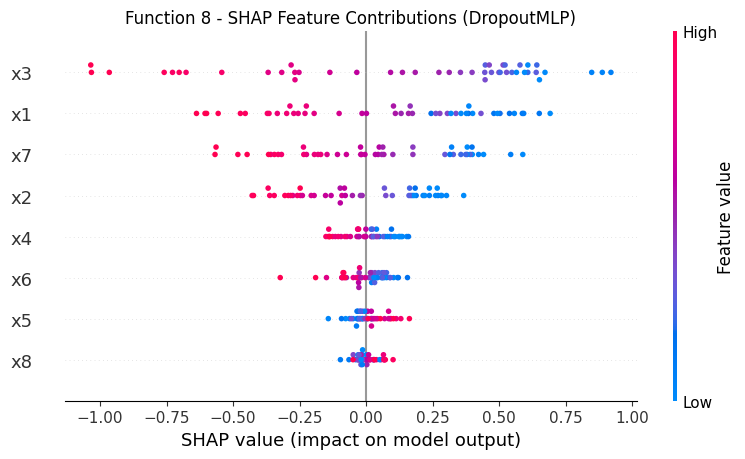


SHAP-derived importance (normalised):
  x1: 0.687  (noise scale: 0.075)
  x2: 0.409  (noise scale: 0.053)
  x3: 1.000  (noise scale: 0.100)
  x4: 0.143  (noise scale: 0.031)
  x5: 0.088  (noise scale: 0.027)
  x6: 0.128  (noise scale: 0.030)
  x7: 0.511  (noise scale: 0.061)
  x8: 0.062  (noise scale: 0.025)

Top 3 points used for local search:
  [0.060495 0.02709  0.006185 0.132068 0.160719 0.354431 0.001361 0.931902] -> output: 9.6200
  [0.022695 0.       0.274348 0.       0.999999 0.127124 0.028034 0.      ] -> output: 9.6264
  [0.182943 0.       0.       0.       0.999999 0.127124 0.092403 0.      ] -> output: 9.6724

Candidate pool: 30000 local + 20000 global = 50000 total
mu   range: 5.268 to 9.832
sigma range: 0.069 to 0.698
kappa*sigma range: 0.117 to 1.187

Week 7 Query: 0.000000-0.000000-0.000000-0.120009-0.144817-0.385066-0.000000-0.986589
MC mu: 9.7899, sigma: 0.3581
UCB:   10.3988


In [10]:
# =============================================================================
# FUNCTION 8 - 8D Black-Box
# changes:
#   -  hybrid candidate generation replaces pure LHS 50k points
#      30k local candidates around top 3 points with SHAP-scaled noise (important dims get wider perturbation) plus 20k global LHS.
#   -  SHAP analysis on DropoutMLP determines which dimensions to perturb more 
#   -  interpretability: added SHAP summary plot on the DropoutMLP via KernelExplainer
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 8 - Week 7")
print("=" * 60)
 
import torch
import torch.nn as nn
 
f8_inputs  = np.load('../Data/function_8/initial_inputs.npy')
f8_outputs = np.load('../Data/function_8/initial_outputs.npy')
 
prev_queries = np.array([
    [0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000],  # W1: 9.672
    [0.022695, 0.000000, 0.274348, 0.000000, 0.999999, 0.127124, 0.028034, 0.000000],  # W2: 9.626
    [0.005086, 0.000000, 0.048567, 0.000000, 0.999999, 0.998962, 0.018674, 0.000000],  # W3: 9.546
    [0.000000, 0.000000, 0.012582, 0.000000, 0.999999, 0.000000, 0.066411, 0.000000],  # W4: 9.552
    [0.143046, 0.934478, 0.256793, 0.378273, 0.985471, 0.743394, 0.090143, 0.014829],  # W5: 9.146
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],  # W6: 9.620
])
prev_outputs = np.array([
    9.6723503773075, 9.6263579169495, 9.5463675507445,
    9.5519471979855, 9.1457303782294, 9.6199985919071,
])
 
all_inputs  = np.vstack([f8_inputs, prev_queries])
all_outputs = np.hstack([f8_outputs, prev_outputs])
 
print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f} (W1)")
 
# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs)
Y_sc = scaler_y.fit_transform(all_outputs.reshape(-1, 1)).ravel()
 
X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)
 
# MLP: hidden=24, dropout=0.2 (same as W6)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)
 
 
# LOO CV -- same as W6, calibration check
loo_errors = []
loo_sigmas = []
 
for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]
 
    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)
 
    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)
 
    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.2)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)
 
    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()
 
    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=50)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]
 
    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)
 
loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)
 
# kappa=1.7 (same as W6)
kappa = 1.7
 
print(f"\nLOO Calibration (true torch model):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {loo_errors.mean() / loo_sigmas.mean():.3f}  (1.0 = perfect calibration)")
print(f"  suggested kappa:     {kappa * (loo_errors.mean() / loo_sigmas.mean()):.2f}")
 
 
# train final model -- same as W6
torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.2)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()
 
model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()
 
print(f"Training loss (final): {loss.item():.4f}")
 
# --- SHAP on the DropoutMLP ---
model.eval()  
 
def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)
 
background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)
 
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()
 
model.train()  # back to train mode for MC dropout predictions
 
# --- Hybrid candidate generation (SHAP-informed) ---
#  local candidates perturb around the top 3 points with noise scaled by SHAP importance
#  20k global LHS for important dimensions to get wider perturbation
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()  # normalise to [0, 1]
 
print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}  (noise scale: {0.02 + 0.08 * shap_importance[i]:.3f})")
 
top_k = 3
best_idx_top = np.argsort(all_outputs)[-top_k:]
best_points = all_inputs[best_idx_top]
 
print(f"\nTop {top_k} points used for local search:")
for i, idx in enumerate(best_idx_top):
    print(f"  {all_inputs[idx]} -> output: {all_outputs[idx]:.4f}")
 
np.random.seed(42)
local_pool = []
for p in best_points:
    noise = np.random.randn(10000, 8)
    for dim in range(8):
        noise[:, dim] *= 0.02 + 0.08 * shap_importance[dim]
    samples = np.clip(p + noise, 0, 1)
    local_pool.append(samples)
 
local_pool = np.vstack(local_pool)
 
global_pool = LatinHypercube(d=8, seed=7).random(n=20000)  # different seed from W6
 
pool = np.vstack([local_pool, global_pool])
print(f"\nCandidate pool: {len(local_pool)} local + {len(global_pool)} global = {len(pool)} total")
 
# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)
 
mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=50)
 
mu    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma = sigma_sc * scaler_y.scale_[0]
 
# UCB with kappa=1.7
ucb   = mu + kappa * sigma
best_idx = np.argmax(ucb)
query    = pool[best_idx]
 
print(f"mu   range: {mu.min():.3f} to {mu.max():.3f}")
print(f"sigma range: {sigma.min():.3f} to {sigma.max():.3f}")
print(f"kappa*sigma range: {(kappa*sigma).min():.3f} to {(kappa*sigma).max():.3f}")
 
print(f"\nWeek 7 Query: {format_query(query)}")
print(f"MC mu: {mu[best_idx]:.4f}, sigma: {sigma[best_idx]:.4f}")
print(f"UCB:   {ucb[best_idx]:.4f}")